<a href="https://colab.research.google.com/github/Ysabellyysa/Python/blob/main/Text_Classification_CNN_Aula.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
!pip install -q tensorflow

In [22]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [23]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense, Input, GlobalMaxPooling1D
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Embedding
from tensorflow.keras.models import Model

In [24]:
# baixa o arquivo spam.csv da internet
!wget https://lazyprogrammer.me/course_files/spam.csv

--2026-06-09 01:04:32--  https://lazyprogrammer.me/course_files/spam.csv
Resolving lazyprogrammer.me (lazyprogrammer.me)... 172.67.213.166, 104.21.23.210, 2606:4700:3030::ac43:d5a6, ...
Connecting to lazyprogrammer.me (lazyprogrammer.me)|172.67.213.166|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 503663 (492K) [text/csv]
Saving to: ‘spam.csv’

spam.csv            100%[===================>] 491.86K  2.02MB/s    in 0.2s    

2026-06-09 01:04:33 (2.02 MB/s) - ‘spam.csv’ saved [503663/503663]



In [33]:
# lê o CSV com encoding para evitar erro de caracteres
df = pd.read_csv('spam.csv', encoding='ISO-8859-1')

In [34]:
# mostra as 5 primeiras linhas do dataframe
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [35]:
#retirando as colunas que não precisa
df = df.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis=1)

In [36]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [38]:
# renomeando colunas
df.columns = ['labels', 'data']

In [39]:
df.head()

,labels,data
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [40]:
# cria uma coluna de labels binário
df['b_labels'] = df['labels'].map({'ham': 0, 'spam': 1})
Y = df['b_labels'].values

In [41]:
# dividindo os dados em treino e teste
df_train, df_test, Ytrain, Ytest = train_test_split(df['data'], Y, test_size=0.33)

In [42]:
# convertendo sentenças em sequências
MAX_VOCAB_SIZE = 20000
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
tokenizer.fit_on_texts(df_train)
sequences_train = tokenizer.texts_to_sequences(df_train)
sequences_test = tokenizer.texts_to_sequences(df_test)

In [43]:
word2idx = tokenizer.word_index
V = len(word2idx)
print('found %s unique tokens' % V)

found 7236 unique tokens


In [44]:
data_train = pad_sequences(sequences_train) # padding para manter o tamanho
print('shape of data train tensor:', data_train.shape)

T = data_train.shape[1] # tamanho da sequência

shape of data train tensor: (3733, 189)


In [45]:
data_test = pad_sequences(sequences_test,
                          maxlen=T # tamanho da sequência
                          ) # padding para manter o tamanho N x T
print('shape of data train tensor:', data_test.shape)

shape of data train tensor: (1839, 189)


In [47]:
D = 20

i = Input(shape=(T,)) # input layer
x = Embedding(V + 1, D)(i)# output layer
x = Conv1D(32, 3, activation='relu')(x) # camada de convolução
x = MaxPooling1D(3)(x) # camada de pooling
x = Conv1D(64, 3, activation='relu')(x)
x = MaxPooling1D(3)(x)
x = Conv1D(128, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)# camada de pooling global
x = Dense(1, activation='sigmoid')(x) # camada densa de saída

model = Model(i, x)

In [48]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

print('Training o model...')
r = model.fit(data_train,
              Ytrain,
              epochs=5,
              validation_data=(data_test, Ytest))

Training o model...
Epoch 1/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8808 - loss: 0.3368 - val_accuracy: 0.9233 - val_loss: 0.1998
Epoch 2/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.9746 - loss: 0.0875 - val_accuracy: 0.9603 - val_loss: 0.1545
Epoch 3/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9904 - loss: 0.0313 - val_accuracy: 0.9766 - val_loss: 0.0918
Epoch 4/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9968 - loss: 0.0107 - val_accuracy: 0.9848 - val_loss: 0.0671
Epoch 5/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9995 - loss: 0.0050 - val_accuracy: 0.9853 - val_loss: 0.0720


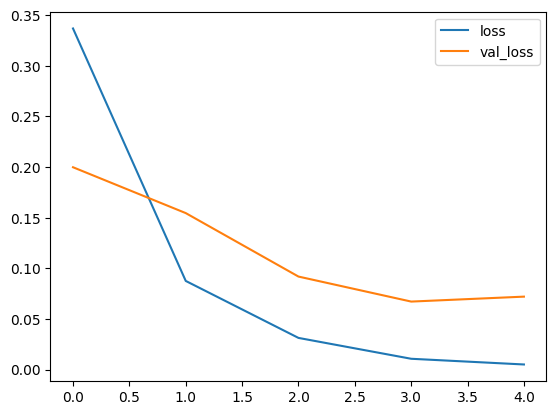

In [49]:
# plotando os resultados de erro
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

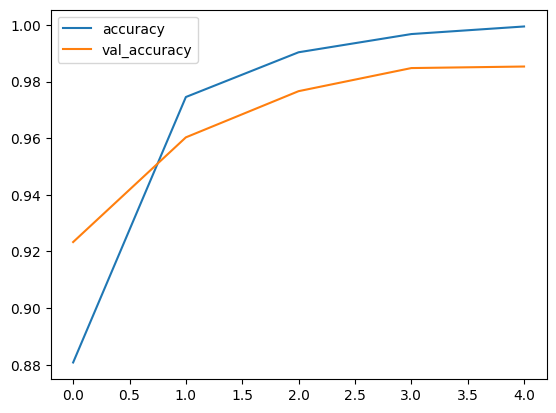

In [50]:
# plotando os resultados
plt.plot(r.history['accuracy'], label='accuracy')
plt.plot(r.history['val_accuracy'], label='val_accuracy')
plt.legend()